In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "machine_learning" else Path.cwd()
PROCESSED_DIR = BASE_DIR / "web_scraping" / "processed"
WEB_DIR = BASE_DIR / "web"

data = pd.read_csv(PROCESSED_DIR / "datos_limpios.csv")


In [2]:
# Agregar metricas por jugador y filtrar por minutos
agg_data = data.groupby("player_name").agg({
    "minutes_played": "sum",
    "goals": "sum",
    "assists": "sum",
    "yellow_cards": "sum",
    "red_cards": "sum",
    "team": "last",
    "position": "last",
}).reset_index()

agg_data = agg_data[agg_data["minutes_played"] > 90].copy()


In [3]:
# Calcular base_score, efficiency, mvp_percentage
agg_data["base_score"] = (
    agg_data["goals"] * 5 +
    agg_data["assists"] * 3 -
    agg_data["yellow_cards"] -
    agg_data["red_cards"] * 3
)

agg_data["efficiency"] = agg_data["base_score"] / (agg_data["minutes_played"] / 90)
agg_data["mvp_score"] = agg_data["base_score"] * 0.7 + agg_data["efficiency"] * 0.3

max_score = agg_data["mvp_score"].max()
agg_data["mvp_percentage"] = (agg_data["mvp_score"] / max_score) * 100

# Obtener Top 10
top10 = agg_data.sort_values("mvp_percentage", ascending=False).head(10)
top10.to_csv(WEB_DIR / "top10_predictions.csv", index=False)


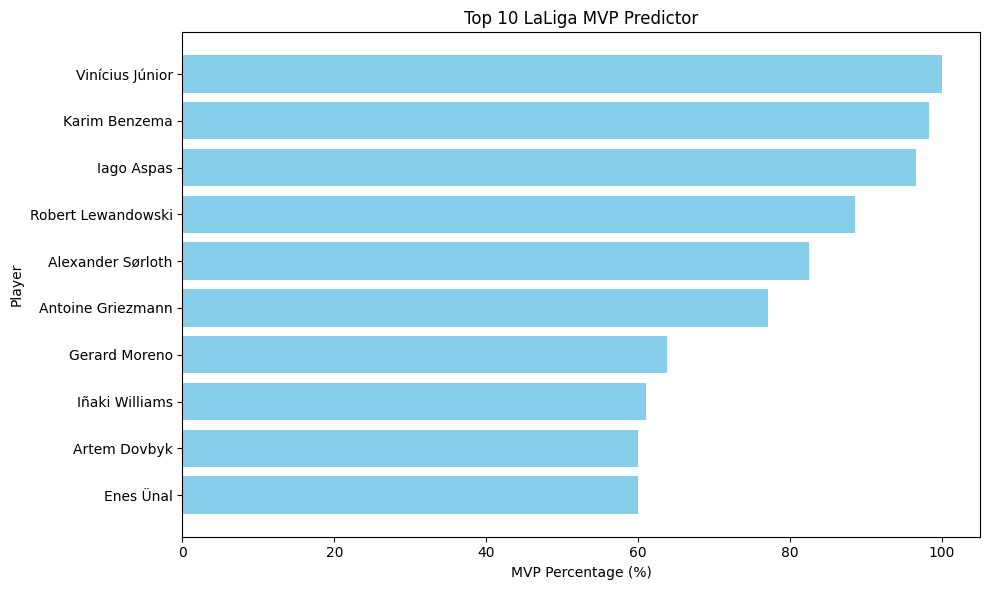

In [4]:
# Generar un grafico de ranking
plt.figure(figsize=(10, 6))
plt.barh(top10["player_name"], top10["mvp_percentage"], color="skyblue")
plt.xlabel("MVP Percentage (%)")
plt.ylabel("Player")
plt.title("Top 10 LaLiga MVP Predictor")
plt.gca().invert_yaxis()
plt.tight_layout()
#plt.savefig(WEB_DIR / "mvp_top10_ranking.png")
plt.show()
